# JobGuard — Data Understanding

## Job Scam Detection & Risk Analytics

This notebook is the first stage of the JobGuard project.

### Objective

Understand the job-posting dataset before performing data cleaning, exploratory analysis, risk analysis, and machine learning.

### Questions

- How large is the dataset?
- What variables are available?
- What does each variable represent?
- How many legitimate and fraudulent postings exist?
- Are there missing values?
- Are there duplicate records?
- What potential data-quality issues need to be addressed?

In [1]:
import pandas as pd

In [2]:
file_path = "../data/raw/fake_job_postings.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 17880
Columns: 18


In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [6]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary.sort_values("missing_percentage", ascending=False)

,missing_count,missing_percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


In [8]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [9]:
fraud_rate = df["fraudulent"].mean() * 100

print(f"Fraudulent job rate: {fraud_rate:.2f}%")
print(f"Legitimate job rate: {100 - fraud_rate:.2f}%")

Fraudulent job rate: 4.84%
Legitimate job rate: 95.16%


In [10]:
df["fraudulent"].unique()

array([0, 1])

In [11]:
df["fraudulent"].isna().sum()


np.int64(0)

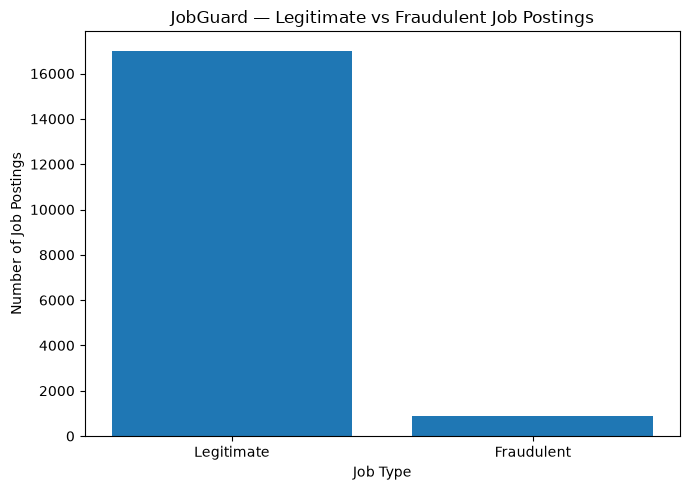

In [12]:
import matplotlib.pyplot as plt

fraud_counts = df["fraudulent"].value_counts().sort_index()

labels = ["Legitimate", "Fraudulent"]

plt.figure(figsize=(7, 5))
plt.bar(labels, fraud_counts.values)

plt.title("JobGuard — Legitimate vs Fraudulent Job Postings")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

In [13]:
df["industry"].nunique()

131

In [14]:
df["industry"].nunique()

131

In [15]:
df["industry"].value_counts(dropna=False).head(15)

industry
NaN                                    4903
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
Name: count, dtype: int64

In [16]:
industry_risk = (
    df.groupby("industry", dropna=False)["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

industry_risk["fraud_rate"] = (industry_risk["fraud_rate"] * 100).round(2)

industry_risk = (
    industry_risk[industry_risk["total_jobs"] >= 50]
    .sort_values("fraud_rate", ascending=False)
)

industry_risk.head(15)

,total_jobs,fraudulent_jobs,fraud_rate
industry,,,
Oil & Energy,287,109,37.98
Accounting,159,57,35.85
"Leisure, Travel & Tourism",76,21,27.63
Hospitality,88,14,15.91
Real Estate,175,24,13.71
"Health, Wellness and Fitness",127,15,11.81
Hospital & Health Care,497,51,10.26
Telecommunications,342,26,7.60
Entertainment,74,5,6.76


In [17]:
industry_risk[industry_risk["total_jobs"] >= 50]

,total_jobs,fraudulent_jobs,fraud_rate
industry,,,
Oil & Energy,287,109,37.98
Accounting,159,57,35.85
"Leisure, Travel & Tourism",76,21,27.63
Hospitality,88,14,15.91
Real Estate,175,24,13.71
"Health, Wellness and Fitness",127,15,11.81
Hospital & Health Care,497,51,10.26
Telecommunications,342,26,7.60
Entertainment,74,5,6.76


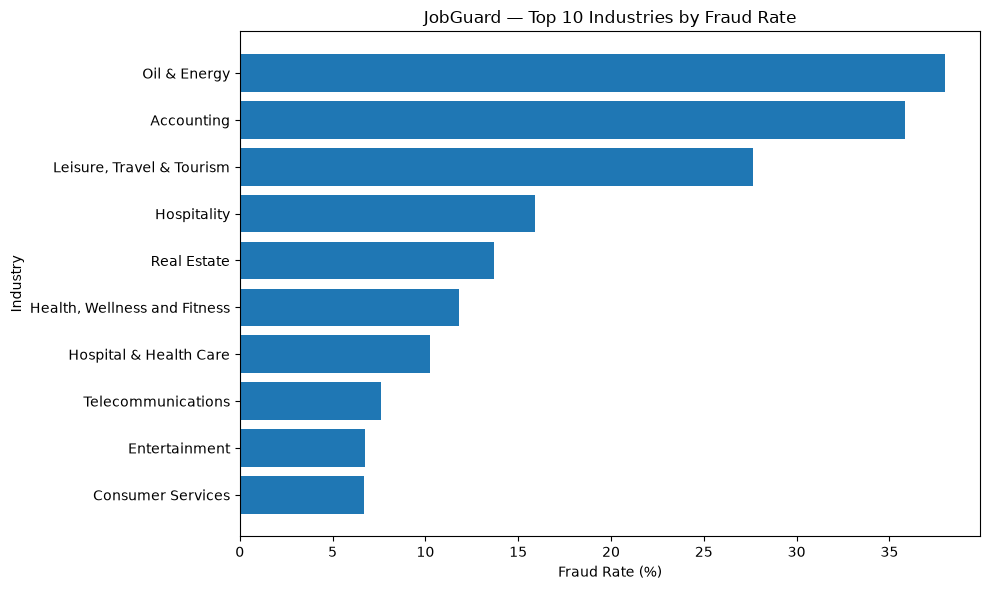

In [19]:
top_industries = industry_risk.head(10).sort_values("fraud_rate")

plt.figure(figsize=(10, 6))

plt.barh(
    top_industries.index.astype(str),
    top_industries["fraud_rate"]
)

plt.title("JobGuard — Top 10 Industries by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()

In [20]:
df["location"].nunique()

3105

In [21]:
df["location"].value_counts(dropna=False).head(20)

location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
NaN                      346
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
US, CA, Los Angeles      185
GB, , London             179
US, TX, Austin           174
US, CA, San Diego        164
GB, ,                    138
US, GA, Atlanta          135
GB, LND,                 131
US, OR, Portland         131
CA, ON, Toronto          123
Name: count, dtype: int64

In [22]:
location_risk = (
    df.groupby("location", dropna=False)["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

location_risk["fraud_rate"] = (
    location_risk["fraud_rate"] * 100
).round(2)

location_risk = (
    location_risk[location_risk["total_jobs"] >= 50]
    .sort_values("fraud_rate", ascending=False)
)

location_risk.head(15)

,total_jobs,fraudulent_jobs,fraud_rate
location,,,
"AU, NSW, Sydney",82,31,37.80
"US, TX, Houston",269,92,34.20
"US, CA, Los Angeles",185,23,12.43
"US, WA, Seattle",57,6,10.53
"US, OH, Cincinnati",91,8,8.79
"US, ,",339,28,8.26
US,63,5,7.94
"US, FL, Jacksonville",50,3,6.00
NaN,346,19,5.49


In [23]:
total_jobs >= 50

NameError: name 'total_jobs' is not defined

In [24]:
len(location_risk)

47

TypeError: 'value' must be an instance of str or bytes, not a float

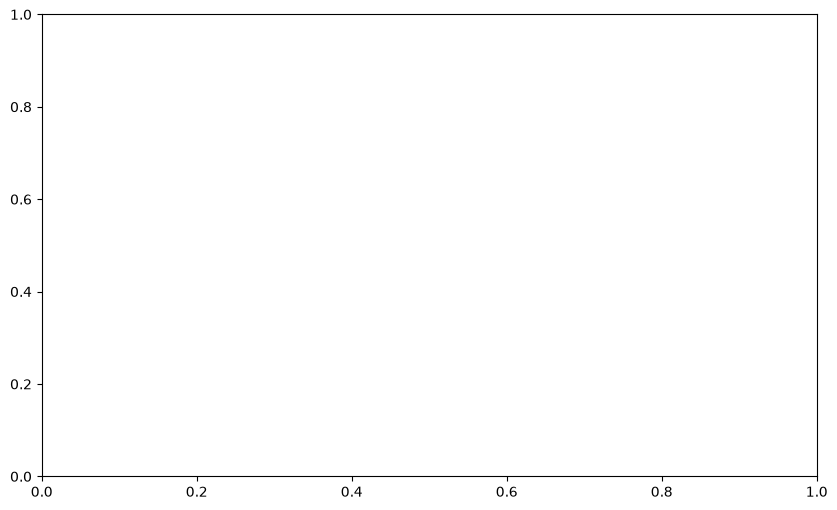

In [25]:
top_locations = location_risk.head(10).sort_values("fraud_rate")

plt.figure(figsize=(10, 6))

plt.barh(
    top_locations.index.astype(str),
    top_locations["fraud_rate"]
)

plt.title("JobGuard — Top 10 Locations by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [26]:
top_locations = location_risk.head(10).sort_values("fraud_rate")

print("Location values:")
print(top_locations.index.tolist())

print("\nFraud rates:")
print(top_locations["fraud_rate"].tolist())

print("\nData types:")
print(top_locations.dtypes)

Location values:
['CA, ON, Toronto', nan, 'US, FL, Jacksonville', 'US', 'US, , ', 'US, OH, Cincinnati', 'US, WA, Seattle', 'US, CA, Los Angeles', 'US, TX, Houston', 'AU, NSW, Sydney']

Fraud rates:
[4.88, 5.49, 6.0, 7.94, 8.26, 8.79, 10.53, 12.43, 34.2, 37.8]

Data types:
total_jobs           int64
fraudulent_jobs      int64
fraud_rate         float64
dtype: object


TypeError: 'value' must be an instance of str or bytes, not a float

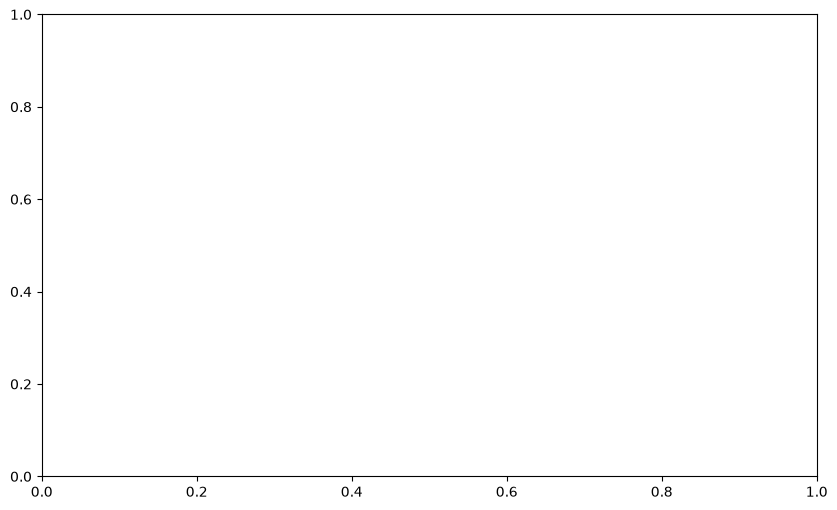

In [27]:
top_locations = location_risk.head(10).sort_values("fraud_rate")

locations = top_locations.index.astype(str).to_numpy()
fraud_rates = top_locations["fraud_rate"].astype(float).to_numpy()

plt.figure(figsize=(10, 6))

plt.barh(locations, fraud_rates)

plt.title("JobGuard — Top 10 Locations by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

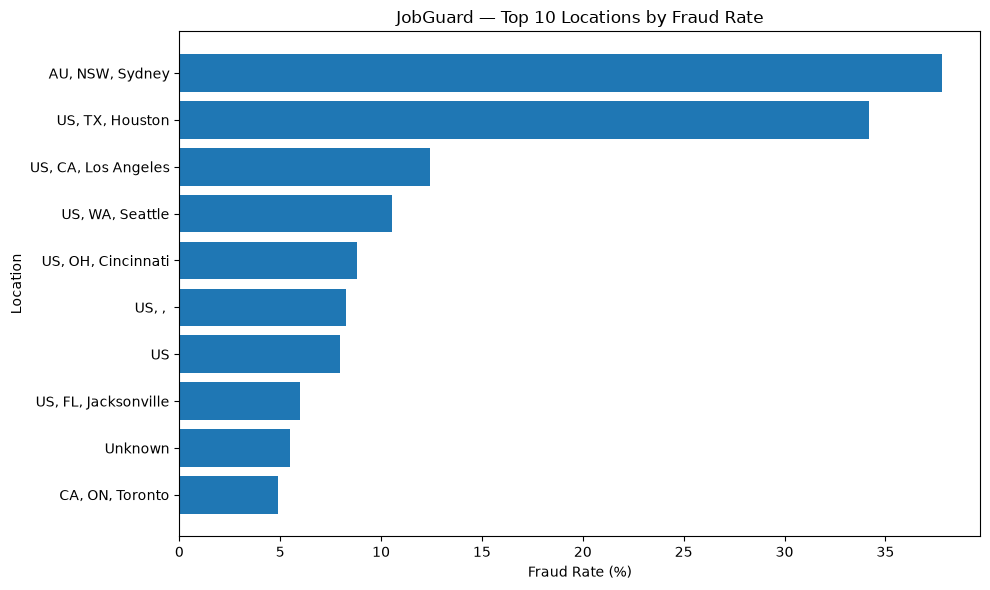

In [28]:
top_locations = location_risk.head(10).sort_values("fraud_rate")

# Convert location names safely to text
location_labels = [
    "Unknown" if pd.isna(location) else str(location)
    for location in top_locations.index
]

fraud_rates = top_locations["fraud_rate"].astype(float).tolist()

# Create numeric positions for the bars
positions = list(range(len(location_labels)))

plt.figure(figsize=(10, 6))

plt.barh(positions, fraud_rates)

plt.yticks(positions, location_labels)

plt.title("JobGuard — Top 10 Locations by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

In [29]:
company_profile_status = df["company_profile"].notna().map({
    True: "Has Company Profile",
    False: "No Company Profile"
})

company_profile_status.value_counts()

company_profile
Has Company Profile    14572
No Company Profile      3308
Name: count, dtype: int64

In [30]:
company_profile_risk = (
    pd.DataFrame({
        "company_profile_status": company_profile_status,
        "fraudulent": df["fraudulent"]
    })
    .groupby("company_profile_status")["fraudulent"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "total_jobs",
        "sum": "fraudulent_jobs",
        "mean": "fraud_rate"
    })
)

company_profile_risk["fraud_rate"] = (
    company_profile_risk["fraud_rate"] * 100
).round(2)

company_profile_risk

,total_jobs,fraudulent_jobs,fraud_rate
company_profile_status,,,
Has Company Profile,14572,279,1.91
No Company Profile,3308,587,17.74


In [31]:
profile_rate = company_profile_risk.loc["Has Company Profile", "fraud_rate"]
no_profile_rate = company_profile_risk.loc["No Company Profile", "fraud_rate"]

risk_multiplier = no_profile_rate / profile_rate

print(f"Fraud rate with company profile: {profile_rate:.2f}%")
print(f"Fraud rate without company profile: {no_profile_rate:.2f}%")
print(f"Observed risk multiplier: {risk_multiplier:.2f}x")

Fraud rate with company profile: 1.91%
Fraud rate without company profile: 17.74%
Observed risk multiplier: 9.29x


In [32]:
df["has_company_logo"].value_counts(dropna=False)

has_company_logo
1    14220
0     3660
Name: count, dtype: int64

In [33]:
logo_risk = (
    df.groupby("has_company_logo")["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

logo_risk["fraud_rate"] = (
    logo_risk["fraud_rate"] * 100
).round(2)

logo_risk

,total_jobs,fraudulent_jobs,fraud_rate
has_company_logo,,,
0,3660,583,15.93
1,14220,283,1.99


In [34]:
no_logo_rate = logo_risk.loc[0, "fraud_rate"]
logo_rate = logo_risk.loc[1, "fraud_rate"]

logo_risk_multiplier = no_logo_rate / logo_rate

print(f"Fraud rate with company logo: {logo_rate:.2f}%")
print(f"Fraud rate without company logo: {no_logo_rate:.2f}%")
print(f"Observed risk multiplier: {logo_risk_multiplier:.2f}x")

Fraud rate with company logo: 1.99%
Fraud rate without company logo: 15.93%
Observed risk multiplier: 8.01x


In [35]:
df["has_questions"].value_counts(dropna=False)

has_questions
0    9088
1    8792
Name: count, dtype: int64

In [36]:
questions_risk = (
    df.groupby("has_questions")["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

questions_risk["fraud_rate"] = (
    questions_risk["fraud_rate"] * 100
).round(2)

questions_risk

,total_jobs,fraudulent_jobs,fraud_rate
has_questions,,,
0,9088,616,6.78
1,8792,250,2.84


In [37]:
no_questions_rate = questions_risk.loc[0, "fraud_rate"]
questions_rate = questions_risk.loc[1, "fraud_rate"]

questions_risk_multiplier = no_questions_rate / questions_rate

print(f"Fraud rate with screening questions: {questions_rate:.2f}%")
print(f"Fraud rate without screening questions: {no_questions_rate:.2f}%")
print(f"Observed risk multiplier: {questions_risk_multiplier:.2f}x")

Fraud rate with screening questions: 2.84%
Fraud rate without screening questions: 6.78%
Observed risk multiplier: 2.39x


In [38]:
df["employment_type"].value_counts(dropna=False)

employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [39]:
employment_risk = (
    df.groupby("employment_type", dropna=False)["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

employment_risk["fraud_rate"] = (
    employment_risk["fraud_rate"] * 100
).round(2)

employment_risk = (
    employment_risk[employment_risk["total_jobs"] >= 50]
    .sort_values("fraud_rate", ascending=False)
)

employment_risk

,total_jobs,fraudulent_jobs,fraud_rate
employment_type,,,
Part-time,797,74,9.28
NaN,3471,241,6.94
Other,227,15,6.61
Full-time,11620,490,4.22
Contract,1524,44,2.89
Temporary,241,2,0.83


In [40]:
df["required_experience"].value_counts(dropna=False)

required_experience
NaN                 7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

In [41]:
experience_risk = (
    df.groupby("required_experience", dropna=False)["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

experience_risk["fraud_rate"] = (
    experience_risk["fraud_rate"] * 100
).round(2)

experience_risk = (
    experience_risk[experience_risk["total_jobs"] >= 50]
    .sort_values("fraud_rate", ascending=False)
)

experience_risk

,total_jobs,fraudulent_jobs,fraud_rate
required_experience,,,
Executive,141,10,7.09
Entry level,2697,179,6.64
NaN,7050,435,6.17
Not Applicable,1116,60,5.38
Director,389,17,4.37
Mid-Senior level,3809,113,2.97
Internship,381,10,2.62
Associate,2297,42,1.83


In [42]:
df["required_education"].value_counts(dropna=False)

required_education
NaN                                  8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

In [43]:
education_risk = (
    df.groupby("required_education", dropna=False)["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

education_risk["fraud_rate"] = (
    education_risk["fraud_rate"] * 100
).round(2)

education_risk = (
    education_risk[education_risk["total_jobs"] >= 50]
    .sort_values("fraud_rate", ascending=False)
)

education_risk

,total_jobs,fraudulent_jobs,fraud_rate
required_education,,,
Certification,170,19,11.18
High School or equivalent,2080,170,8.17
Master's Degree,416,31,7.45
NaN,8105,451,5.56
Professional,74,4,5.41
Unspecified,1397,61,4.37
Some College Coursework Completed,102,3,2.94
Associate Degree,274,6,2.19
Bachelor's Degree,5145,100,1.94


In [44]:
df["description_length"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.len()
)

df[["description_length", "fraudulent"]].groupby("fraudulent").agg(
    ["count", "mean", "median", "min", "max"]
)

description_length                                
                        count         mean  median min    max
fraudulent                                                   
0                       17014  1221.219701  1027.0   6  14907
1                         866  1154.834873   844.5   0   8578

In [45]:
df["description_word_count"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

word_count_risk = (
    df.groupby("fraudulent")["description_word_count"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

word_count_risk

,count,mean,median,min,max
fraudulent,,,,,
0,17014,171.04,147.0,1,2115
1,866,158.75,113.5,0,1183


In [46]:
text_risk_summary = (
    df.groupby("fraudulent")[
        ["description_length", "description_word_count"]
    ]
    .agg(["mean", "median"])
    .round(2)
)

text_risk_summary

description_length         description_word_count       
                         mean  median                   mean median
fraudulent                                                         
0                     1221.22  1027.0                 171.04  147.0
1                     1154.83   844.5                 158.75  113.5

In [47]:
risk_keywords = {
    "money_payment": r"\b(payment|pay|money|fee|fees|deposit)\b",
    "bank_financial": r"\b(bank|banking|account|credit card|debit card)\b",
    "urgent_action": r"\b(urgent|immediately|asap|act now)\b",
    "guaranteed_income": r"\b(guaranteed income|guaranteed salary|easy money|quick money)\b"
}

risk_keywords

{'money_payment': '\\b(payment|pay|money|fee|fees|deposit)\\b',
 'bank_financial': '\\b(bank|banking|account|credit card|debit card)\\b',
 'urgent_action': '\\b(urgent|immediately|asap|act now)\\b',
 'guaranteed_income': '\\b(guaranteed income|guaranteed salary|easy money|quick money)\\b'}

In [48]:
description_text = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

for feature_name, pattern in risk_keywords.items():
    df[feature_name] = description_text.str.contains(
        pattern,
        regex=True,
        na=False
    )

df[list(risk_keywords.keys())].head()

C:\Users\kodha\AppData\Local\Temp\ipykernel_15416\2190884448.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[feature_name] = description_text.str.contains(


,money_payment,bank_financial,urgent_action,guaranteed_income
0,False,False,False,False
1,False,True,False,False
2,False,False,False,False
3,True,True,False,False
4,True,False,False,False


In [49]:
for feature_name, pattern in risk_keywords.items():

_IncompleteInputError: incomplete input (716278055.py, line 1)

In [50]:
keyword_prevalence = (
    df.groupby("fraudulent")[list(risk_keywords.keys())]
      .mean()
      .mul(100)
      .round(2)
)

keyword_prevalence

,money_payment,bank_financial,urgent_action,guaranteed_income
fraudulent,,,,
0,7.22,8.79,3.85,0.01
1,19.63,9.35,5.43,0.00


In [51]:
legitimate_prevalence = keyword_prevalence.loc[0]
fraudulent_prevalence = keyword_prevalence.loc[1]

keyword_risk_ratio = (
    fraudulent_prevalence / legitimate_prevalence
).replace([float("inf"), -float("inf")], pd.NA)

keyword_risk_ratio = keyword_risk_ratio.round(2)

keyword_risk_ratio.sort_values(ascending=False)

money_payment        2.72
urgent_action        1.41
bank_financial       1.06
guaranteed_income    0.00
dtype: float64

In [52]:
risk_signal_summary = pd.DataFrame({
    "risk_signal": [
        "Industry",
        "Location",
        "Company Profile",
        "Company Logo",
        "Screening Questions",
        "Employment Type",
        "Required Experience",
        "Required Education",
        "Description Length",
        "Description Word Count",
        "Money / Payment Language",
        "Bank / Financial Language",
        "Urgent Action Language",
        "Guaranteed Income Language"
    ],
    
    "analysis_type": [
        "Historical fraud rate",
        "Historical fraud rate",
        "Presence vs absence",
        "Presence vs absence",
        "Presence vs absence",
        "Category-level fraud rate",
        "Category-level fraud rate",
        "Category-level fraud rate",
        "Text statistic",
        "Text statistic",
        "Keyword prevalence",
        "Keyword prevalence",
        "Keyword prevalence",
        "Keyword prevalence"
    ],
    
    "purpose": [
        "Identify industries with elevated observed fraud rates",
        "Identify locations with elevated observed fraud rates",
        "Test whether missing company information is associated with fraud",
        "Test whether missing company branding is associated with fraud",
        "Test whether screening-question availability differs by fraud label",
        "Compare fraud rates across employment arrangements",
        "Compare fraud rates across experience requirements",
        "Compare fraud rates across education requirements",
        "Measure job-description size in characters",
        "Measure job-description size in words",
        "Detect payment-related language",
        "Detect financial or banking-related language",
        "Detect urgency-related language",
        "Detect guaranteed-income language"
    ]
})

risk_signal_summary

,risk_signal,analysis_type,purpose
0,Industry,Historical fraud rate,Identify industries with elevated observed fra...
1,Location,Historical fraud rate,Identify locations with elevated observed frau...
2,Company Profile,Presence vs absence,Test whether missing company information is as...
3,Company Logo,Presence vs absence,Test whether missing company branding is assoc...
4,Screening Questions,Presence vs absence,Test whether screening-question availability d...
5,Employment Type,Category-level fraud rate,Compare fraud rates across employment arrangem...
6,Required Experience,Category-level fraud rate,Compare fraud rates across experience requirem...
7,Required Education,Category-level fraud rate,Compare fraud rates across education requirements
8,Description Length,Text statistic,Measure job-description size in characters
9,Description Word Count,Text statistic,Measure job-description size in words


In [53]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [55]:
duplicate_job_ids = df["job_id"].duplicated().sum()

print(f"Duplicate job IDs: {duplicate_job_ids}")

Duplicate job IDs: 0


In [56]:
df["job_id"].duplicated().sum()

np.int64(0)

In [57]:
print(f"Duplicate job IDs: {duplicate_job_ids}")

Duplicate job IDs: 0


In [58]:
missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_report = (
    missing_report
    .sort_values("missing_percentage", ascending=False)
)

missing_report

,missing_count,missing_percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


In [59]:
missing_report[missing_report["missing_count"] > 0]

,missing_count,missing_percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


In [60]:
missing_report["severity"] = pd.cut(
    missing_report["missing_percentage"],
    bins=[-0.01, 5, 20, 50, 100],
    labels=[
        "Very Low (<5%)",
        "Moderate (5–20%)",
        "High (20–50%)",
        "Very High (>50%)"
    ]
)

missing_report

,missing_count,missing_percentage,severity
salary_range,15012,83.96,Very High (>50%)
department,11547,64.58,Very High (>50%)
required_education,8105,45.33,High (20–50%)
benefits,7212,40.34,High (20–50%)
required_experience,7050,39.43,High (20–50%)
function,6455,36.10,High (20–50%)
industry,4903,27.42,High (20–50%)
employment_type,3471,19.41,Moderate (5–20%)
company_profile,3308,18.50,Moderate (5–20%)
requirements,2696,15.08,Moderate (5–20%)


In [61]:
description_missing = df["description"].isna()

description_missing_risk = (
    df.groupby(description_missing)["fraudulent"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total_jobs",
          "sum": "fraudulent_jobs",
          "mean": "fraud_rate"
      })
)

description_missing_risk["fraud_rate"] = (
    description_missing_risk["fraud_rate"] * 100
).round(2)

description_missing_risk.index = [
    "Description Present",
    "Description Missing"
]

description_missing_risk

,total_jobs,fraudulent_jobs,fraud_rate
Description Present,17879,865,4.84
Description Missing,1,1,100.00


In [62]:
df["description"].fillna("")

0        Food52, a fast-growing, James Beard Award-winn...
1        Organised - Focused - Vibrant - Awesome!Do you...
2        Our client, located in Houston, is actively se...
3        THE COMPANY: ESRI – Environmental Systems Rese...
4        JOB TITLE: Itemization Review ManagerLOCATION:...
                               ...                        
17875    Just in case this is the first time you’ve vis...
17876    The Payroll Accountant will focus primarily on...
17877    Experienced Project Cost Control Staff Enginee...
17878    Nemsia Studios is looking for an experienced v...
17879    Who are we?Vend is an award winning web based ...
Name: description, Length: 17880, dtype: str

In [63]:
df_processed = df.copy()

print("Processed dataset copy created.")
print("Original rows:", len(df))
print("Processed rows:", len(df_processed))

Processed dataset copy created.
Original rows: 17880
Processed rows: 17880


In [64]:
df_processed["description_was_missing"] = (
    df_processed["description"].isna().astype(int)
)

df_processed["description_was_missing"].value_counts()

description_was_missing
0    17879
1        1
Name: count, dtype: int64

In [65]:
df_processed["description"] = (
    df_processed["description"]
    .fillna("")
    .astype(str)
)

In [66]:
df_processed["description"].isna().sum()

np.int64(0)

In [67]:
df_processed["company_profile_was_missing"] = (
    df_processed["company_profile"].isna().astype(int)
)

df_processed["company_profile_was_missing"].value_counts()

company_profile_was_missing
0    14572
1     3308
Name: count, dtype: int64

In [68]:
df_processed["company_profile"] = (
    df_processed["company_profile"]
    .fillna("")
    .astype(str)
)

print(
    "Missing company profiles after cleaning:",
    df_processed["company_profile"].isna().sum()
)

Missing company profiles after cleaning: 0


In [69]:
df_processed["location_was_missing"] = (
    df_processed["location"].isna().astype(int)
)

df_processed["location_was_missing"].value_counts()

location_was_missing
0    17534
1      346
Name: count, dtype: int64

In [70]:
df_processed["location"] = (
    df_processed["location"]
    .fillna("Unknown")
    .astype(str)
)

print(
    "Missing locations after cleaning:",
    df_processed["location"].isna().sum()
)

Missing locations after cleaning: 0


In [71]:
df_processed["location"] = (
    df_processed["location"]
    .fillna("Unknown")
    .astype(str)
)

print(
    "Missing locations after cleaning:",
    df_processed["location"].isna().sum()
)

Missing locations after cleaning: 0


In [72]:
df_processed["salary_was_missing"] = (
    df_processed["salary_range"].isna().astype(int)
)

df_processed["salary_was_missing"].value_counts()

salary_was_missing
1    15012
0     2868
Name: count, dtype: int64

In [73]:
df_processed["salary_range"].dropna().head(20)

6        20000-28000
10     100000-120000
15     120000-150000
23     100000-120000
31       50000-65000
42       40000-50000
65             60-80
76       65000-70000
77            75-115
79      75000-110000
91       17000-20000
92       16000-28000
98      95000-115000
102      15000-18000
107      50000-70000
113      45000-60000
132      30000-40000
134      70000-90000
145      10000-14000
152           50-110
Name: salary_range, dtype: str

In [74]:
salary_values = (
    df_processed["salary_range"]
    .fillna("")
    .astype(str)
)

salary_parts = salary_values.str.split("-", n=1, expand=True)

df_processed["salary_min"] = pd.to_numeric(
    salary_parts[0],
    errors="coerce"
)

df_processed["salary_max"] = pd.to_numeric(
    salary_parts[1],
    errors="coerce"
)

df_processed[[
    "salary_range",
    "salary_min",
    "salary_max"
]].head(20)

,salary_range,salary_min,salary_max
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,20000-28000,20000.0,28000.0
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


In [75]:
df_processed["salary_midpoint"] = (
    df_processed["salary_min"] +
    df_processed["salary_max"]
) / 2

df_processed[
    ["salary_min", "salary_max", "salary_midpoint"]
].head(20)

,salary_min,salary_max,salary_midpoint
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,20000.0,28000.0,24000.0
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


In [76]:
salary_validation = df_processed[
    ["salary_range", "salary_min", "salary_max", "salary_midpoint"]
].copy()

print("Total job postings:", len(salary_validation))
print("Salary ranges provided:", df_processed["salary_range"].notna().sum())
print("Salary minimum extracted:", df_processed["salary_min"].notna().sum())
print("Salary maximum extracted:", df_processed["salary_max"].notna().sum())
print("Salary midpoint calculated:", df_processed["salary_midpoint"].notna().sum())

Total job postings: 17880
Salary ranges provided: 2868
Salary minimum extracted: 2863
Salary maximum extracted: 2846
Salary midpoint calculated: 2841


In [77]:
df_processed[
    ["salary_min", "salary_max", "salary_midpoint"]
].describe()


,salary_min,salary_max,salary_midpoint
count,2.863000e+03,2.846000e+03,2.841000e+03
mean,5.116296e+05,8.111440e+05,6.640744e+05
std,1.762815e+07,2.703359e+07,2.237353e+07
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.800000e+04,2.500000e+04,2.200000e+04
50%,3.500000e+04,5.000000e+04,4.500000e+04
75%,6.000000e+04,9.000000e+04,7.250000e+04
max,8.000000e+08,1.200000e+09,1.000000e+09


In [78]:
invalid_salary_ranges = (
    df_processed["salary_min"].notna()
    & df_processed["salary_max"].notna()
    & (
        df_processed["salary_min"]
        > df_processed["salary_max"]
    )
)

print(
    "Invalid salary ranges:",
    invalid_salary_ranges.sum()
)

Invalid salary ranges: 0


In [79]:
salary_risk = (
    df_processed.groupby("fraudulent")[
        ["salary_min", "salary_max", "salary_midpoint"]
    ]
    .agg(["count", "mean", "median"])
    .round(2)
)

salary_risk

salary_min                     salary_max                      \
                count       mean   median      count       mean   median   
fraudulent                                                                 
0                2641  549054.20  36000.0       2623  866568.82  50000.0   
1                 222   66411.11  30000.0        223  159218.71  45000.0   

           salary_midpoint                      
                     count       mean   median  
fraudulent                                      
0                     2619  710771.65  45000.0  
1                      222  113173.46  37500.0

In [80]:
salary_plot_data = df_processed[
    ["fraudulent", "salary_midpoint"]
].dropna()

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        salary_plot_data.loc[
            salary_plot_data["fraudulent"] == 0,
            "salary_midpoint"
        ],
        salary_plot_data.loc[
            salary_plot_data["fraudulent"] == 1,
            "salary_midpoint"
        ]
    ],
    labels=["Legitimate", "Fraudulent"],
    showfliers=False
)

plt.title("JobGuard — Salary Midpoint Distribution")
plt.xlabel("Job Type")
plt.ylabel("Salary Midpoint")

plt.tight_layout()
plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

<Figure size 800x500 with 0 Axes>

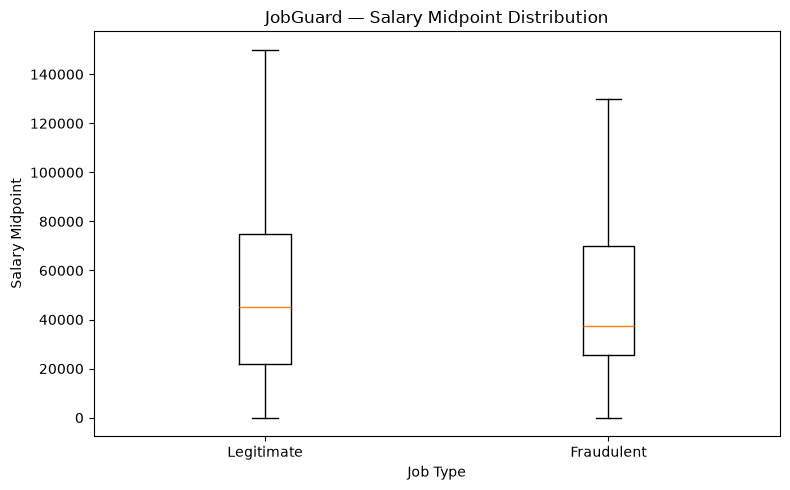

In [81]:
salary_plot_data = df_processed[
    ["fraudulent", "salary_midpoint"]
].dropna()

legitimate_salary = salary_plot_data.loc[
    salary_plot_data["fraudulent"] == 0,
    "salary_midpoint"
]

fraudulent_salary = salary_plot_data.loc[
    salary_plot_data["fraudulent"] == 1,
    "salary_midpoint"
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        legitimate_salary,
        fraudulent_salary
    ],
    tick_labels=["Legitimate", "Fraudulent"],
    showfliers=False
)

plt.title("JobGuard — Salary Midpoint Distribution")
plt.xlabel("Job Type")
plt.ylabel("Salary Midpoint")

plt.tight_layout()
plt.show()

In [82]:
df_processed["requirements_was_missing"] = (
    df_processed["requirements"].isna().astype(int)
)

df_processed["requirements_was_missing"].value_counts()

requirements_was_missing
0    15184
1     2696
Name: count, dtype: int64

In [83]:
df_processed["requirements"] = (
    df_processed["requirements"]
    .fillna("")
    .astype(str)
)

print(
    "Missing requirements after cleaning:",
    df_processed["requirements"].isna().sum()
)

Missing requirements after cleaning: 0


In [84]:
df_processed["benefits_was_missing"] = (
    df_processed["benefits"].isna().astype(int)
)

df_processed["benefits"] = (
    df_processed["benefits"]
    .fillna("")
    .astype(str)
)

print(
    "Missing benefits after cleaning:",
    df_processed["benefits"].isna().sum()
)

Missing benefits after cleaning: 0


In [85]:
df_processed["requirements_length"] = (
    df_processed["requirements"]
    .str.len()
)

df_processed["requirements_word_count"] = (
    df_processed["requirements"]
    .str.split()
    .str.len()
)

df_processed["benefits_length"] = (
    df_processed["benefits"]
    .str.len()
)

df_processed["benefits_word_count"] = (
    df_processed["benefits"]
    .str.split()
    .str.len()
)

df_processed[
    [
        "requirements_length",
        "requirements_word_count",
        "benefits_length",
        "benefits_word_count"
    ]
].head()

,requirements_length,requirements_word_count,benefits_length,benefits_word_count
0,852,115,0,0
1,1433,200,1292,227
2,1363,164,0,0
3,1429,176,782,97
4,757,89,21,3


In [86]:
text_section_risk = (
    df_processed.groupby("fraudulent")[
        [
            "description_length",
            "description_word_count",
            "requirements_length",
            "requirements_word_count",
            "benefits_length",
            "benefits_word_count"
        ]
    ]
    .agg(["mean", "median"])
    .round(2)
)

text_section_risk

description_length         description_word_count         \
                         mean  median                   mean median   
fraudulent                                                            
0                     1221.22  1027.0                 171.04  147.0   
1                     1154.83   844.5                 158.75  113.5   

           requirements_length        requirements_word_count         \
                          mean median                    mean median   
fraudulent                                                             
0                       597.47  476.5                   79.03   63.0   
1                       446.05  249.0                   58.41   34.0   

           benefits_length        benefits_word_count         
                      mean median                mean median  
fraudulent                                                    
0                   208.73   47.0               30.02    6.0  
1                   212.20   36.0               29.45    5.0

In [87]:
processed_missing = pd.DataFrame({
    "missing_count": df_processed.isna().sum(),
    "missing_percentage": (
        df_processed.isna().mean() * 100
    ).round(2)
})

processed_missing = (
    processed_missing[
        processed_missing["missing_count"] > 0
    ]
    .sort_values("missing_percentage", ascending=False)
)

processed_missing

,missing_count,missing_percentage
salary_midpoint,15039,84.11
salary_max,15034,84.08
salary_min,15017,83.99
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41


In [88]:
categorical_columns = [
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for column in categorical_columns:
    df_processed[f"{column}_was_missing"] = (
        df_processed[column].isna().astype(int)
    )

    df_processed[column] = (
        df_processed[column]
        .fillna("Unknown")
        .astype(str)
    )

print("Categorical missing-value treatment completed.")

Categorical missing-value treatment completed.


In [89]:
for column in categorical_columns:
    print(
        f"{column}:",
        df_processed[column].isna().sum(),
        "missing values"
    )

department: 0 missing values
employment_type: 0 missing values
required_experience: 0 missing values
required_education: 0 missing values
industry: 0 missing values
function: 0 missing values


In [90]:
remaining_missing = pd.DataFrame({
    "missing_count": df_processed.isna().sum(),
    "missing_percentage": (
        df_processed.isna().mean() * 100
    ).round(2)
})

remaining_missing = (
    remaining_missing[
        remaining_missing["missing_count"] > 0
    ]
    .sort_values("missing_percentage", ascending=False)
)

remaining_missing

,missing_count,missing_percentage
salary_midpoint,15039,84.11
salary_max,15034,84.08
salary_min,15017,83.99
salary_range,15012,83.96


In [91]:
print("===== JobGuard Final Cleaning Validation =====")

print("\nRows:")
print("Original:", len(df))
print("Processed:", len(df_processed))

print("\nColumns:")
print("Original:", len(df.columns))
print("Processed:", len(df_processed.columns))

print("\nTarget distribution:")
print(df_processed["fraudulent"].value_counts())

print("\nTarget missing values:")
print(df_processed["fraudulent"].isna().sum())

print("\nExact duplicate rows:")
print(df_processed.duplicated().sum())

print("\nDuplicate job IDs:")
print(df_processed["job_id"].duplicated().sum())

===== JobGuard Final Cleaning Validation =====

Rows:
Original: 17880
Processed: 17880

Columns:
Original: 24
Processed: 43

Target distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Target missing values:
0

Exact duplicate rows:
0

Duplicate job IDs:
0


In [92]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

processed_file = processed_dir / "jobguard_processed.csv"

df_processed.to_csv(
    processed_file,
    index=False
)

print("Processed dataset saved successfully!")
print("File:", processed_file)
print("Rows:", len(df_processed))
print("Columns:", len(df_processed.columns))


Processed dataset saved successfully!
File: ..\data\processed\jobguard_processed.csv
Rows: 17880
Columns: 43


In [93]:
X = df_processed.drop(columns=["fraudulent"])
y = df_processed["fraudulent"]

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Feature dataset shape: (17880, 42)
Target shape: (17880,)

Target distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Target percentages:
fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64


In [94]:
feature_type_summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "unique_values": X.nunique(),
    "missing_values": X.isna().sum()
})

feature_type_summary

,dtype,unique_values,missing_values
job_id,int64,17880,0
title,str,11231,0
location,str,3106,0
department,str,1337,0
salary_range,str,874,15012
company_profile,str,1710,0
description,str,14802,0
requirements,str,11968,0
benefits,str,6205,0
telecommuting,int64,2,0


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training features: (14304, 42)
Testing features: (3576, 42)

Training target distribution:
fraudulent
0    0.9516
1    0.0484
Name: proportion, dtype: float64

Testing target distribution:
fraudulent
0    0.9516
1    0.0484
Name: proportion, dtype: float64


In [96]:
numeric_features = [
    "salary_min",
    "salary_max",
    "salary_midpoint",
    "description_length",
    "description_word_count",
    "requirements_length",
    "requirements_word_count",
    "benefits_length",
    "benefits_word_count",
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "description_was_missing",
    "company_profile_was_missing",
    "requirements_was_missing",
    "benefits_was_missing",
    "location_was_missing",
    "salary_was_missing"
]

print("Numeric features:", len(numeric_features))
print(numeric_features)

Numeric features: 18
['salary_min', 'salary_max', 'salary_midpoint', 'description_length', 'description_word_count', 'requirements_length', 'requirements_word_count', 'benefits_length', 'benefits_word_count', 'telecommuting', 'has_company_logo', 'has_questions', 'description_was_missing', 'company_profile_was_missing', 'requirements_was_missing', 'benefits_was_missing', 'location_was_missing', 'salary_was_missing']


In [97]:
categorical_features = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "department"
]

print("Categorical features:", len(categorical_features))
print(categorical_features)


Categorical features: 6
['employment_type', 'required_experience', 'required_education', 'industry', 'function', 'department']


In [98]:
text_features = [
    "title",
    "description",
    "requirements",
    "benefits"
]

print("Text features:", len(text_features))
print(text_features)

Text features: 4
['title', 'description', 'requirements', 'benefits']


In [99]:
selected_features = (
    numeric_features +
    categorical_features +
    text_features
)

missing_selected_features = [
    column for column in selected_features
    if column not in X_train.columns
]

print("Selected features:", len(selected_features))
print("Missing selected features:", missing_selected_features)

Selected features: 28
Missing selected features: []


In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

print("Scikit-learn preprocessing tools imported successfully.")

Scikit-learn preprocessing tools imported successfully.


In [101]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numeric preprocessing pipeline created.")

Numeric preprocessing pipeline created.


In [102]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [103]:
title_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

description_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

requirements_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

benefits_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english"
)

print("TF-IDF vectorizers created.")

TF-IDF vectorizers created.


In [104]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
        (
            "title_tfidf",
            title_vectorizer,
            "title"
        ),
        (
            "description_tfidf",
            description_vectorizer,
            "description"
        ),
        (
            "requirements_tfidf",
            requirements_vectorizer,
            "requirements"
        ),
        (
            "benefits_tfidf",
            benefits_vectorizer,
            "benefits"
        )
    ],
    remainder="drop"
)

print("Combined preprocessing pipeline created.")

Combined preprocessing pipeline created.


In [105]:
X_train_processed = preprocessor.fit_transform(X_train)

print("Training data transformed successfully.")
print("Processed training shape:", X_train_processed.shape)

Training data transformed successfully.
Processed training shape: (14304, 24377)


In [106]:
X_test_processed = preprocessor.transform(X_test)

print("Test data transformed successfully.")
print("Processed test shape:", X_test_processed.shape)

Test data transformed successfully.
Processed test shape: (3576, 24377)


In [107]:
print("Training matrix type:", type(X_train_processed))
print("Test matrix type:", type(X_test_processed))

print("Training matrix shape:", X_train_processed.shape)
print("Test matrix shape:", X_test_processed.shape)

Training matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Test matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Training matrix shape: (14304, 24377)
Test matrix shape: (3576, 24377)


In [108]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully.")

Logistic Regression imported successfully.


In [109]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("JobGuard Logistic Regression model created.")

JobGuard Logistic Regression model created.


In [110]:
logistic_model.fit(
    X_train_processed,
    y_train
)

print("JobGuard Logistic Regression trained successfully.")


JobGuard Logistic Regression trained successfully.


In [111]:
y_pred = logistic_model.predict(X_test_processed)

y_proba = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated.")
print("Number of predictions:", len(y_pred))
print("Number of probabilities:", len(y_proba))

Predictions generated.
Number of predictions: 3576
Number of probabilities: 3576


In [112]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraudulent"],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9938    0.9880    0.9909      3403
  Fraudulent     0.7876    0.8786    0.8306       173

    accuracy                         0.9827      3576
   macro avg     0.8907    0.9333    0.9107      3576
weighted avg     0.9838    0.9827    0.9831      3576



Confusion Matrix:
[[3362   41]
 [  21  152]]


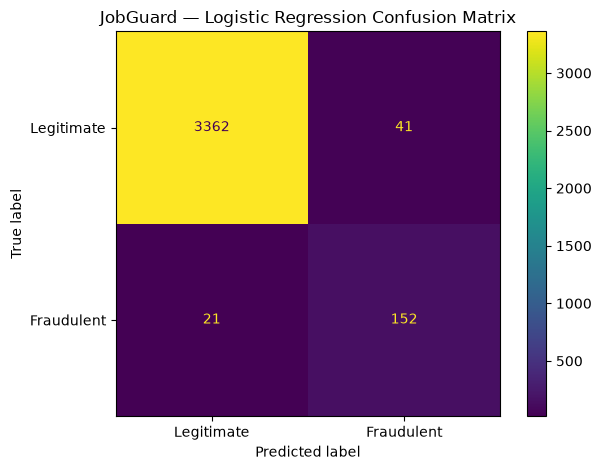

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraudulent"]
).plot()

plt.title("JobGuard — Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

In [114]:
from sklearn.metrics import average_precision_score, roc_auc_score

pr_auc = average_precision_score(
    y_test,
    y_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print(f"PR-AUC:  {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

PR-AUC:  0.9096
ROC-AUC: 0.9837


In [115]:
baseline_results = pd.DataFrame({
    "model": ["Logistic Regression"],
    "precision_fraud": [
        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )["1"]["precision"]
    ],
    "recall_fraud": [
        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )["1"]["recall"]
    ],
    "f1_fraud": [
        classification_report(
            y_test,
            y_pred,
            output_dict=True
        )["1"]["f1-score"]
    ],
    "pr_auc": [pr_auc],
    "roc_auc": [roc_auc]
})

baseline_results.round(4)


,model,precision_fraud,recall_fraud,f1_fraud,pr_auc,roc_auc
0,Logistic Regression,0.7876,0.8786,0.8306,0.9096,0.9837


In [116]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    
    threshold_pred = (
        y_proba >= threshold
    ).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,threshold,precision,recall,f1
0,0.10,0.2987,0.9480,0.4543
1,0.15,0.3863,0.9422,0.5479
2,0.20,0.4441,0.9191,0.5989
3,0.25,0.5096,0.9191,0.6557
4,0.30,0.5683,0.9133,0.7007
5,0.35,0.6420,0.9017,0.7500
6,0.40,0.7051,0.8844,0.7846
7,0.45,0.7308,0.8786,0.7979
8,0.50,0.7876,0.8786,0.8306
9,0.55,0.8242,0.8671,0.8451


In [117]:
best_threshold_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold_row)

Best threshold based on F1:
threshold    0.700000
precision    0.939597
recall       0.809249
f1           0.869565
Name: 12, dtype: float64


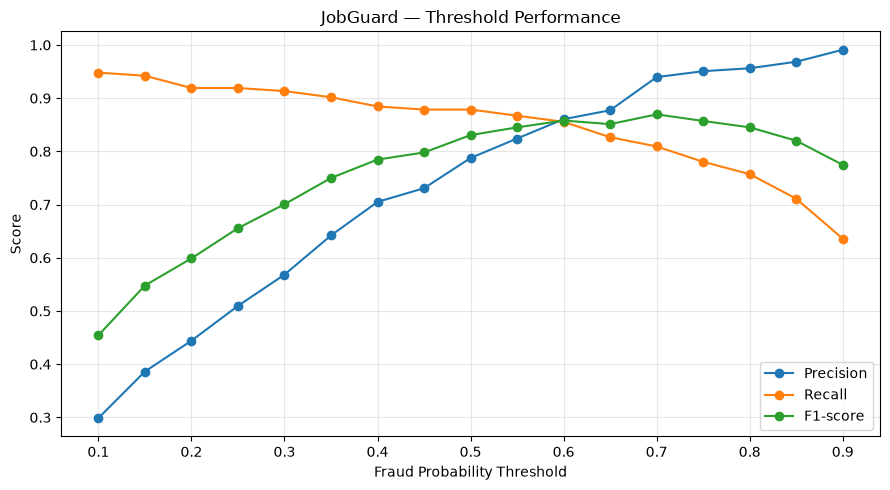

In [118]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Fraud Probability Threshold")
plt.ylabel("Score")
plt.title("JobGuard — Threshold Performance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [119]:
jobguard_risk_score = (
    y_proba * 100
).round(1)

print("Example JobGuard risk scores:")
print(jobguard_risk_score[:20])

Example JobGuard risk scores:
[23.5  1.   2.4  0.4  1.   0.9  1.1 24.9  0.2 30.8  0.6  1.7  0.1  1.2
  0.3  1.7  0.   0.3  8.5  5.9]


In [120]:
def risk_level(score):
    if score < 30:
        return "Low Risk"
    elif score < 60:
        return "Medium Risk"
    elif score < 80:
        return "High Risk"
    else:
        return "Very High Risk"


risk_levels = pd.Series(
    jobguard_risk_score
).apply(risk_level)

print(risk_levels.value_counts())

Low Risk          3298
Very High Risk     137
Medium Risk        106
High Risk           35
Name: count, dtype: int64


In [121]:
jobguard_predictions = pd.DataFrame({
    "actual_fraudulent": y_test.to_numpy(),
    "predicted_fraudulent": y_pred,
    "fraud_probability": y_proba.round(4),
    "risk_score": jobguard_risk_score,
    "risk_level": risk_levels.to_numpy()
})

jobguard_predictions.head(20)

,actual_fraudulent,predicted_fraudulent,fraud_probability,risk_score,risk_level
0,0,0,0.2345,23.5,Low Risk
1,0,0,0.0104,1.0,Low Risk
2,0,0,0.0236,2.4,Low Risk
3,0,0,0.0040,0.4,Low Risk
4,0,0,0.0104,1.0,Low Risk
5,0,0,0.0091,0.9,Low Risk
6,0,0,0.0105,1.1,Low Risk
7,0,0,0.2486,24.9,Low Risk
8,0,0,0.0018,0.2,Low Risk
9,0,0,0.3075,30.8,Medium Risk


In [122]:
high_risk_indices = (
    jobguard_predictions
    .sort_values("risk_score", ascending=False)
    .head(10)
    .index
)

high_risk_jobs = X_test.iloc[high_risk_indices].copy()

high_risk_jobs["risk_score"] = (
    jobguard_predictions
    .loc[high_risk_indices, "risk_score"]
    .to_numpy()
)

high_risk_jobs[
    ["title", "location", "employment_type", "risk_score"]
]

,title,location,employment_type,risk_score
14133,Subsea Process System Engineer,"US, TX, Houston",Unknown,99.9
6301,HSE Manager,"US, TX, Houston",Unknown,99.9
11739,UST Testing Technician,"US, CA, Bakersfield, CA",Full-time,99.8
7662,Data Entry Office Support,"US, MI, Detroit",Unknown,99.7
5506,Home Based Payroll Data Entry Clerk Position -...,"US, GA, Abbeville",Unknown,99.7
6056,Payroll Data Entry Clerk Position - Earn $100...,"US, PA, Aaronsburg",Full-time,99.7
2977,Administrative Assistant/Customer Service,"US, CA, San diego",Full-time,99.7
5505,Home Based Payroll Data Entry Clerk Position -...,"US, SC, Abbeville",Unknown,99.7
9263,IC&E Technician,"US, CA, Bakersfield, CA / Mt. Poso",Full-time,99.7
15928,Administrative Positions,"US, CA, Long Beach",Part-time,99.7


In [123]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("Number of model coefficients:", len(logistic_model.coef_[0]))

Number of processed features: 24377
Number of model coefficients: 24377


In [124]:
coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": logistic_model.coef_[0]
})

top_fraud_features = (
    coefficient_table
    .sort_values("coefficient", ascending=False)
    .head(20)
)

top_fraud_features

,feature,coefficient
133,categorical__industry_Oil & Energy,2.933504
775,categorical__department_Information Technology,2.917247
2051,title_tfidf__customer assistant,2.793026
774,categorical__department_Information Technology,2.748941
947,categorical__department_Oil & Energy,2.699645
16434,requirements_tfidf__high school,2.182447
1827,title_tfidf__center,2.174691
3375,title_tfidf__position,2.172163
9420,description_tfidf__link,2.008534
1829,title_tfidf__center representative,1.954708


In [125]:
top_legitimate_features = (
    coefficient_table
    .sort_values("coefficient", ascending=True)
    .head(20)
)

top_legitimate_features

,feature,coefficient
192,categorical__function_Health Care Provider,-2.110896
156,categorical__industry_Restaurants,-2.014923
13234,description_tfidf__team,-1.824024
106,categorical__industry_Internet,-1.684466
15816,requirements_tfidf__english,-1.625453
1578,title_tfidf__architect,-1.406805
1529,title_tfidf__analyst,-1.404268
7338,description_tfidf__end,-1.300813
9096,description_tfidf__join,-1.293961
867,categorical__department_Marketing,-1.285808


In [126]:
top_fraud = (
    coefficient_table
    .nlargest(15, "coefficient")
    .assign(direction="Fraud-associated")
)

top_legitimate = (
    coefficient_table
    .nsmallest(15, "coefficient")
    .assign(direction="Legitimate-associated")
)

explainability_summary = pd.concat(
    [top_fraud, top_legitimate]
)

explainability_summary

,feature,coefficient,direction
133,categorical__industry_Oil & Energy,2.933504,Fraud-associated
775,categorical__department_Information Technology,2.917247,Fraud-associated
2051,title_tfidf__customer assistant,2.793026,Fraud-associated
774,categorical__department_Information Technology,2.748941,Fraud-associated
947,categorical__department_Oil & Energy,2.699645,Fraud-associated
16434,requirements_tfidf__high school,2.182447,Fraud-associated
1827,title_tfidf__center,2.174691,Fraud-associated
3375,title_tfidf__position,2.172163,Fraud-associated
9420,description_tfidf__link,2.008534,Fraud-associated
1829,title_tfidf__center representative,1.954708,Fraud-associated


In [127]:
example_position = 0

example_job = X_test.iloc[[example_position]]
example_actual = y_test.iloc[example_position]

example_probability = logistic_model.predict_proba(
    preprocessor.transform(example_job)
)[0, 1]

print("Actual label:", example_actual)
print("Fraud probability:", round(example_probability, 4))
print("Risk score:", round(example_probability * 100, 1))

Actual label: 0
Fraud probability: 0.2345
Risk score: 23.5


In [128]:
example_processed = preprocessor.transform(example_job)

if hasattr(example_processed, "toarray"):
    example_dense = example_processed.toarray()
else:
    example_dense = example_processed

example_contributions = pd.DataFrame({
    "feature": feature_names,
    "value": example_dense[0],
    "coefficient": logistic_model.coef_[0]
})

example_contributions["contribution"] = (
    example_contributions["value"]
    * example_contributions["coefficient"]
)

example_contributions = (
    example_contributions[
        example_contributions["value"] != 0
    ]
    .sort_values("contribution", ascending=False)
)

example_contributions.head(20)

,feature,value,coefficient,contribution
13,numeric__company_profile_was_missing,2.086455,0.766572,1.599419
96,categorical__industry_Hospital & Health Care,1.000000,1.371846,1.371846
3661,title_tfidf__rn,0.488370,1.735761,0.847694
6,numeric__requirements_word_count,-0.952175,-0.658868,0.627357
31,categorical__required_experience_Unknown,1.000000,0.421784,0.421784
3251,title_tfidf__opportunity,0.478134,0.610452,0.291878
13496,description_tfidf__time,0.105311,1.654343,0.174221
12046,description_tfidf__rn,0.307428,0.546923,0.168140
11,numeric__has_questions,-0.985976,-0.156929,0.154728
15,numeric__benefits_was_missing,1.210344,0.113580,0.137471


In [129]:
top_risk_factors = (
    example_contributions
    .nlargest(10, "contribution")
)

top_risk_factors[
    ["feature", "value", "coefficient", "contribution"]
]



,feature,value,coefficient,contribution
13,numeric__company_profile_was_missing,2.086455,0.766572,1.599419
96,categorical__industry_Hospital & Health Care,1.000000,1.371846,1.371846
3661,title_tfidf__rn,0.488370,1.735761,0.847694
6,numeric__requirements_word_count,-0.952175,-0.658868,0.627357
31,categorical__required_experience_Unknown,1.000000,0.421784,0.421784
3251,title_tfidf__opportunity,0.478134,0.610452,0.291878
13496,description_tfidf__time,0.105311,1.654343,0.174221
12046,description_tfidf__rn,0.307428,0.546923,0.168140
11,numeric__has_questions,-0.985976,-0.156929,0.154728
15,numeric__benefits_was_missing,1.210344,0.113580,0.137471


In [130]:
top_legitimate_factors = (
    example_contributions
    .nsmallest(10, "contribution")
)

top_legitimate_factors[
    ["feature", "value", "coefficient", "contribution"]
]

,feature,value,coefficient,contribution
192,categorical__function_Health Care Provider,1.000000,-2.110896,-2.110896
1291,categorical__department_Unknown,1.000000,-0.550409,-0.550409
5,numeric__requirements_length,-0.958637,0.533798,-0.511719
10,numeric__has_company_logo,0.510923,-0.465597,-0.237884
41,categorical__required_education_Unknown,1.000000,-0.208006,-0.208006
5865,description_tfidf__client,0.161593,-1.161899,-0.187755
4503,description_tfidf__50,0.140675,-0.928885,-0.130671
13234,description_tfidf__team,0.049316,-1.824024,-0.089953
5278,description_tfidf__based,0.073777,-1.118178,-0.082496
9931,description_tfidf__medical,0.204643,-0.385150,-0.078818


In [131]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [132]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("JobGuard Random Forest model created.")

JobGuard Random Forest model created.


In [133]:
random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [134]:
rf_pred = random_forest_model.predict(
    X_test_processed
)

rf_proba = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated.")
print("Predictions:", len(rf_pred))
print("Probabilities:", len(rf_proba))

Random Forest predictions generated.
Predictions: 3576
Probabilities: 3576


In [135]:
rf_report = classification_report(
    y_test,
    rf_pred,
    target_names=["Legitimate", "Fraudulent"],
    output_dict=True
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_proba
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_proba
)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Legitimate", "Fraudulent"],
        digits=4
    )
)

print(f"PR-AUC:  {rf_pr_auc:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")

              precision    recall  f1-score   support

  Legitimate     0.9868    0.9868    0.9868      3403
  Fraudulent     0.7399    0.7399    0.7399       173

    accuracy                         0.9748      3576
   macro avg     0.8633    0.8633    0.8633      3576
weighted avg     0.9748    0.9748    0.9748      3576

PR-AUC:  0.8436
ROC-AUC: 0.9773


In [136]:
model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "precision_fraud": baseline_results.loc[
            0, "precision_fraud"
        ],
        "recall_fraud": baseline_results.loc[
            0, "recall_fraud"
        ],
        "f1_fraud": baseline_results.loc[
            0, "f1_fraud"
        ],
        "pr_auc": baseline_results.loc[
            0, "pr_auc"
        ],
        "roc_auc": baseline_results.loc[
            0, "roc_auc"
        ]
    },
    {
        "model": "Random Forest",
        "precision_fraud": rf_report["1"]["precision"],
        "recall_fraud": rf_report["1"]["recall"],
        "f1_fraud": rf_report["1"]["f1-score"],
        "pr_auc": rf_pr_auc,
        "roc_auc": rf_roc_auc
    }
])

model_comparison.round(4)


KeyError: '1'

In [137]:
from sklearn.metrics import precision_score, recall_score, f1_score

rf_precision = precision_score(
    y_test,
    rf_pred,
    pos_label=1,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    pos_label=1,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    pos_label=1,
    zero_division=0
)

model_comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "precision_fraud": precision_score(
            y_test,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "recall_fraud": recall_score(
            y_test,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "f1_fraud": f1_score(
            y_test,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    },
    {
        "model": "Random Forest",
        "precision_fraud": rf_precision,
        "recall_fraud": rf_recall,
        "f1_fraud": rf_f1,
        "pr_auc": rf_pr_auc,
        "roc_auc": rf_roc_auc
    }
])

model_comparison.round(4)

,model,precision_fraud,recall_fraud,f1_fraud,pr_auc,roc_auc
0,Logistic Regression,0.7876,0.8786,0.8306,0.9096,0.9837
1,Random Forest,0.7399,0.7399,0.7399,0.8436,0.9773


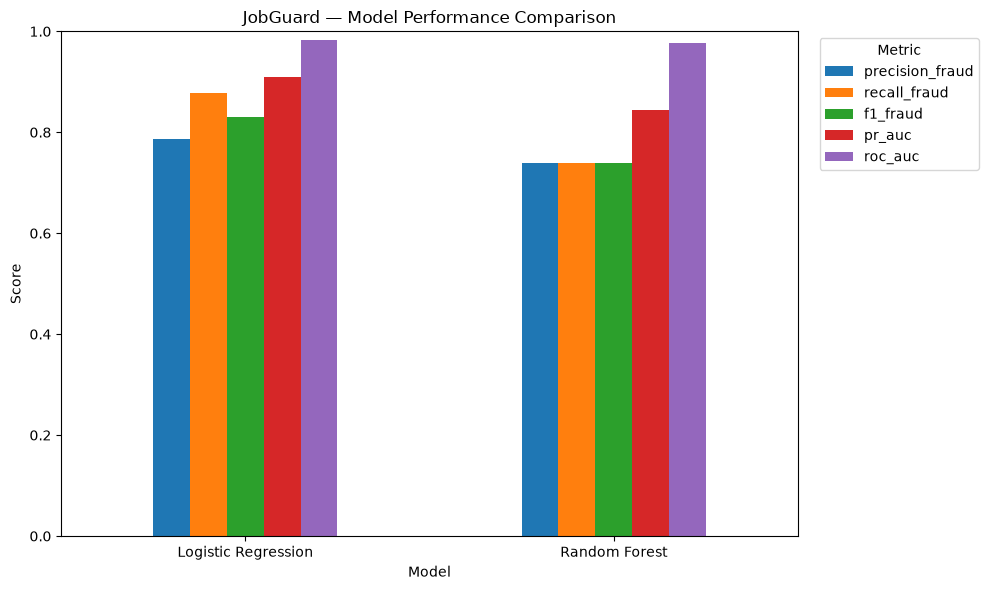

In [138]:
comparison_plot = model_comparison.set_index("model")[
    [
        "precision_fraud",
        "recall_fraud",
        "f1_fraud",
        "pr_auc",
        "roc_auc"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("JobGuard — Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [139]:
best_model_by_f1 = model_comparison.loc[
    model_comparison["f1_fraud"].idxmax()
]

best_model_by_pr_auc = model_comparison.loc[
    model_comparison["pr_auc"].idxmax()
]

print("Best model by Fraud F1:")
print(best_model_by_f1)

print("\nBest model by PR-AUC:")
print(best_model_by_pr_auc)

Best model by Fraud F1:
model              Logistic Regression
precision_fraud               0.787565
recall_fraud                  0.878613
f1_fraud                      0.830601
pr_auc                        0.909588
roc_auc                       0.983651
Name: 0, dtype: object

Best model by PR-AUC:
model              Logistic Regression
precision_fraud               0.787565
recall_fraud                  0.878613
f1_fraud                      0.830601
pr_auc                        0.909588
roc_auc                       0.983651
Name: 0, dtype: object


In [140]:
model_decision = model_comparison.copy()

model_decision["recall_rank"] = (
    model_decision["recall_fraud"]
    .rank(ascending=False, method="min")
)

model_decision["f1_rank"] = (
    model_decision["f1_fraud"]
    .rank(ascending=False, method="min")
)

model_decision["pr_auc_rank"] = (
    model_decision["pr_auc"]
    .rank(ascending=False, method="min")
)

model_decision["overall_rank"] = (
    model_decision[
        [
            "recall_rank",
            "f1_rank",
            "pr_auc_rank"
        ]
    ]
    .mean(axis=1)
)

model_decision.sort_values(
    "overall_rank"
).round(4)

,model,precision_fraud,recall_fraud,f1_fraud,pr_auc,roc_auc,recall_rank,f1_rank,pr_auc_rank,overall_rank
0,Logistic Regression,0.7876,0.8786,0.8306,0.9096,0.9837,1.0,1.0,1.0,1.0
1,Random Forest,0.7399,0.7399,0.7399,0.8436,0.9773,2.0,2.0,2.0,2.0


In [141]:
# Select the best model using our comparison ranking

best_model_name = (
    model_decision
    .sort_values("overall_rank")
    .iloc[0]["model"]
)

print("Selected final model:", best_model_name)

if best_model_name == "Logistic Regression":
    final_model = logistic_model
    final_proba = y_proba
else:
    final_model = random_forest_model
    final_proba = rf_proba

print("Final model object ready.")

Selected final model: Logistic Regression
Final model object ready.


In [142]:
final_threshold_results = []

for threshold in [
    0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45,
    0.50, 0.55, 0.60, 0.65,
    0.70, 0.75, 0.80, 0.85, 0.90
]:
    
    threshold_pred = (
        final_proba >= threshold
    ).astype(int)
    
    final_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

final_threshold_results = pd.DataFrame(
    final_threshold_results
)

best_final_threshold = (
    final_threshold_results
    .loc[
        final_threshold_results["f1"].idxmax(),
        "threshold"
    ]
)

print(
    "Best threshold for final model:",
    best_final_threshold
)

print("\nThreshold performance:")
print(
    final_threshold_results
    .round(4)
)

Best threshold for final model: 0.7

Threshold performance:
    threshold  precision  recall      f1
0        0.10     0.2987  0.9480  0.4543
1        0.15     0.3863  0.9422  0.5479
2        0.20     0.4441  0.9191  0.5989
3        0.25     0.5096  0.9191  0.6557
4        0.30     0.5683  0.9133  0.7007
5        0.35     0.6420  0.9017  0.7500
6        0.40     0.7051  0.8844  0.7846
7        0.45     0.7308  0.8786  0.7979
8        0.50     0.7876  0.8786  0.8306
9        0.55     0.8242  0.8671  0.8451
10       0.60     0.8605  0.8555  0.8580
11       0.65     0.8773  0.8266  0.8512
12       0.70     0.9396  0.8092  0.8696
13       0.75     0.9507  0.7803  0.8571
14       0.80     0.9562  0.7572  0.8452
15       0.85     0.9685  0.7110  0.8200
16       0.90     0.9910  0.6358  0.7746


In [143]:
final_pred = (
    final_proba >= best_final_threshold
).astype(int)

print(
    classification_report(
        y_test,
        final_pred,
        target_names=[
            "Legitimate",
            "Fraudulent"
        ],
        digits=4
    )
)

final_pr_auc = average_precision_score(
    y_test,
    final_proba
)

final_roc_auc = roc_auc_score(
    y_test,
    final_proba
)

print(f"Final PR-AUC:  {final_pr_auc:.4f}")
print(f"Final ROC-AUC: {final_roc_auc:.4f}")

              precision    recall  f1-score   support

  Legitimate     0.9904    0.9974    0.9939      3403
  Fraudulent     0.9396    0.8092    0.8696       173

    accuracy                         0.9883      3576
   macro avg     0.9650    0.9033    0.9317      3576
weighted avg     0.9879    0.9883    0.9878      3576

Final PR-AUC:  0.9096
Final ROC-AUC: 0.9837


In [144]:
final_model_metadata = {
    "model_name": best_model_name,
    "threshold": float(best_final_threshold),
    "pr_auc": float(final_pr_auc),
    "roc_auc": float(final_roc_auc),
    "feature_count": int(X_train_processed.shape[1]),
    "train_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0])
}

final_model_metadata

{'model_name': 'Logistic Regression',
 'threshold': 0.7,
 'pr_auc': 0.9095884293405873,
 'roc_auc': 0.9836509438288896,
 'feature_count': 24377,
 'train_rows': 14304,
 'test_rows': 3576}

In [145]:
import joblib
from pathlib import Path

model_dir = Path("../src/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "jobguard_model.joblib"
preprocessor_path = model_dir / "jobguard_preprocessor.joblib"
metadata_path = model_dir / "jobguard_metadata.joblib"

joblib.dump(
    final_model,
    model_path
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

joblib.dump(
    final_model_metadata,
    metadata_path
)

print("JobGuard model saved successfully!")
print("Model:", model_path)
print("Preprocessor:", preprocessor_path)
print("Metadata:", metadata_path)

JobGuard model saved successfully!
Model: ..\src\models\jobguard_model.joblib
Preprocessor: ..\src\models\jobguard_preprocessor.joblib
Metadata: ..\src\models\jobguard_metadata.joblib


In [146]:
print("Model exists:", model_path.exists())
print("Preprocessor exists:", preprocessor_path.exists())
print("Metadata exists:", metadata_path.exists())

Model exists: True
Preprocessor exists: True
Metadata exists: True


In [147]:
def predict_job_risk(job_data):
    """
    Predict fraud risk for a single job posting.
    """

    # Convert input into a DataFrame
    job_df = pd.DataFrame([job_data])

    # Apply the same preprocessing used during training
    processed_job = preprocessor.transform(job_df)

    # Get fraud probability
    fraud_probability = final_model.predict_proba(
        processed_job
    )[0, 1]

    # Convert probability to 0-100 risk score
    risk_score = round(
        fraud_probability * 100,
        1
    )

    # Determine risk level
    if risk_score < 30:
        risk_level = "Low Risk"
    elif risk_score < 60:
        risk_level = "Medium Risk"
    elif risk_score < 80:
        risk_level = "High Risk"
    else:
        risk_level = "Very High Risk"

    # Apply selected classification threshold
    prediction = int(
        fraud_probability >= best_final_threshold
    )

    prediction_label = (
        "Fraudulent"
        if prediction == 1
        else "Legitimate"
    )

    return {
        "fraud_probability": round(
            fraud_probability,
            4
        ),
        "risk_score": risk_score,
        "risk_level": risk_level,
        "prediction": prediction,
        "prediction_label": prediction_label
    }


print("JobGuard prediction function created.")

JobGuard prediction function created.


In [148]:
test_job = X_test.iloc[0].to_dict()

test_prediction = predict_job_risk(
    test_job
)

test_prediction

{'fraud_probability': np.float64(0.2345),
 'risk_score': np.float64(23.5),
 'risk_level': 'Low Risk',
 'prediction': 0,
 'prediction_label': 'Legitimate'}

In [149]:
def display_jobguard_result(result):
    print("=" * 45)
    print("             JOBGUARD RESULT")
    print("=" * 45)

    print(
        f"Prediction       : "
        f"{result['prediction_label']}"
    )

    print(
        f"Fraud Probability: "
        f"{result['fraud_probability']:.2%}"
    )

    print(
        f"Risk Score       : "
        f"{result['risk_score']}/100"
    )

    print(
        f"Risk Level       : "
        f"{result['risk_level']}"
    )

    print("=" * 45)

In [150]:
display_jobguard_result(
    test_prediction
)

             JOBGUARD RESULT
Prediction       : Legitimate
Fraud Probability: 23.45%
Risk Score       : 23.5/100
Risk Level       : Low Risk


In [151]:
preprocessor
final_model
best_final_threshold

np.float64(0.7)

In [152]:
loaded_model = joblib.load(
    model_path
)

loaded_preprocessor = joblib.load(
    preprocessor_path
)

loaded_metadata = joblib.load(
    metadata_path
)

print("Saved JobGuard components loaded successfully.")

print(
    "Model:",
    type(loaded_model).__name__
)

print(
    "Threshold:",
    loaded_metadata["threshold"]
)

Saved JobGuard components loaded successfully.
Model: LogisticRegression
Threshold: 0.7


In [153]:
loaded_processed_job = loaded_preprocessor.transform(
    X_test.iloc[[0]]
)

loaded_probability = loaded_model.predict_proba(
    loaded_processed_job
)[0, 1]

print(
    "Loaded model fraud probability:",
    round(loaded_probability, 4)
)

print(
    "Original model fraud probability:",
    round(
        test_prediction["fraud_probability"],
        4
    )
)

Loaded model fraud probability: 0.2345
Original model fraud probability: 0.2345


In [159]:
import re
import numpy as np
import pandas as pd


# ============================================================
# 1. SALARY PARSER
# ============================================================

def parse_salary_range(salary_range):
    """
    Convert salary text into:
    salary_min, salary_max, salary_midpoint

    Examples:
        "50000-70000"
        "50,000-70,000"
        "60000"
    """

    if salary_range is None:
        return np.nan, np.nan, np.nan

    salary_text = str(salary_range).strip()

    if salary_text == "":
        return np.nan, np.nan, np.nan

    # Remove commas before extracting numbers
    salary_text = salary_text.replace(",", "")

    numbers = re.findall(
        r"\d+(?:\.\d+)?",
        salary_text
    )

    numbers = [float(x) for x in numbers]

    if len(numbers) >= 2:

        salary_min = numbers[0]
        salary_max = numbers[1]

        salary_midpoint = (
            salary_min + salary_max
        ) / 2

        return (
            salary_min,
            salary_max,
            salary_midpoint
        )

    elif len(numbers) == 1:

        salary_min = numbers[0]
        salary_max = numbers[0]
        salary_midpoint = numbers[0]

        return (
            salary_min,
            salary_max,
            salary_midpoint
        )

    return np.nan, np.nan, np.nan


print("Salary parser created successfully.")

Salary parser created successfully.


In [ ]:
def prepare_job_input(
    title="",
    location="",
    department="",
    salary_range="",
    company_profile="",
    description="",
    requirements="",
    benefits="",
    employment_type="",
    required_experience="",
    required_education="",
    industry="",
    function="",
    telecommuting=0,
    has_company_logo=0,
    has_questions=0
):
    """
    Convert normal job-posting inputs into the
    feature structure expected by the JobGuard model.
    """

    # Convert text fields to strings
    title = "" if title is None else str(title)
    location = "" if location is None else str(location)
    department = "" if department is None else str(department)
    company_profile = (
        "" if company_profile is None
        else str(company_profile)
    )
    description = (
        "" if description is None
        else str(description)
    )
    requirements = (
        "" if requirements is None
        else str(requirements)
    )
    benefits = (
        "" if benefits is None
        else str(benefits)
    )

    employment_type = (
        "" if employment_type is None
        else str(employment_type)
    )

    required_experience = (
        "" if required_experience is None
        else str(required_experience)
    )

    required_education = (
        "" if required_education is None
        else str(required_education)
    )

    industry = (
        "" if industry is None
        else str(industry)
    )

    function = (
        "" if function is None
        else str(function)
    )

    # Salary features
    salary_min, salary_max, salary_midpoint = (
        parse_salary_range(salary_range)
    )

    # Missingness indicators
    location_was_missing = int(
        location.strip() == ""
    )

    salary_was_missing = int(
        salary_range is None
        or str(salary_range).strip() == ""
        or np.isnan(salary_midpoint)
    )

    company_profile_was_missing = int(
        company_profile.strip() == ""
    )

    description_was_missing = int(
        description.strip() == ""
    )

    requirements_was_missing = int(
        requirements.strip() == ""
    )

    benefits_was_missing = int(
        benefits.strip() == ""
    )

    # Text features
    description_length = len(description)

    description_word_count = len(
        description.split()
    )

    requirements_length = len(requirements)

    requirements_word_count = len(
        requirements.split()
    )

    benefits_length = len(benefits)

    benefits_word_count = len(
        benefits.split()
    )

    # Build model input
    job_input = {
        "salary_min": salary_min,
        "salary_max": salary_max,
        "salary_midpoint": salary_midpoint,

        "description_length": description_length,
        "description_word_count": description_word_count,

        "requirements_length": requirements_length,
        "requirements_word_count": requirements_word_count,

        "benefits_length": benefits_length,
        "benefits_word_count": benefits_word_count,

        "telecommuting": int(telecommuting),
        "has_company_logo": int(has_company_logo),
        "has_questions": int(has_questions),

        "description_was_missing": description_was_missing,
        "company_profile_was_missing": (
            company_profile_was_missing
        ),
        "requirements_was_missing": (
            requirements_was_missing
        ),
        "benefits_was_missing": (
            benefits_was_missing
        ),
        "location_was_missing": (
            location_was_missing
        ),
        "salary_was_missing": (
            salary_was_missing
        ),

        "employment_type": employment_type,
        "required_experience": (
            required_experience
        ),
        "required_education": (
            required_education
        ),
        "industry": industry,
        "function": function,
        "department": department,

        "title": title,
        "description": description,
        "requirements": requirements,
        "benefits": benefits
    }

    return pd.DataFrame([job_input])


print("Job input feature builder created successfully.")

Job input feature builder created successfully.


In [160]:
import re
import numpy as np
import pandas as pd


# ============================================================
# 1. SALARY PARSER
# ============================================================

def parse_salary_range(salary_range):
    """
    Convert salary text into:
    salary_min, salary_max, salary_midpoint

    Examples:
        "50000-70000"
        "50,000-70,000"
        "60000"
    """

    if salary_range is None:
        return np.nan, np.nan, np.nan

    salary_text = str(salary_range).strip()

    if salary_text == "":
        return np.nan, np.nan, np.nan

    # Remove commas before extracting numbers
    salary_text = salary_text.replace(",", "")

    numbers = re.findall(
        r"\d+(?:\.\d+)?",
        salary_text
    )

    numbers = [float(x) for x in numbers]

    if len(numbers) >= 2:

        salary_min = numbers[0]
        salary_max = numbers[1]

        salary_midpoint = (
            salary_min + salary_max
        ) / 2

        return (
            salary_min,
            salary_max,
            salary_midpoint
        )

    elif len(numbers) == 1:

        salary_min = numbers[0]
        salary_max = numbers[0]
        salary_midpoint = numbers[0]

        return (
            salary_min,
            salary_max,
            salary_midpoint
        )

    return np.nan, np.nan, np.nan


print("Salary parser created successfully.")


# ============================================================
# 2. PREPARE RAW JOB INPUT
# ============================================================

def prepare_job_input(
    title="",
    location="",
    department="",
    salary_range="",
    company_profile="",
    description="",
    requirements="",
    benefits="",
    employment_type="",
    required_experience="",
    required_education="",
    industry="",
    function="",
    telecommuting=0,
    has_company_logo=0,
    has_questions=0
):
    """
    Convert normal job-posting information into the
    exact feature structure required by JobGuard.
    """

    # --------------------------------------------------------
    # Convert text values safely to strings
    # --------------------------------------------------------

    title = "" if title is None else str(title)
    location = "" if location is None else str(location)
    department = "" if department is None else str(department)

    company_profile = (
        "" if company_profile is None
        else str(company_profile)
    )

    description = (
        "" if description is None
        else str(description)
    )

    requirements = (
        "" if requirements is None
        else str(requirements)
    )

    benefits = (
        "" if benefits is None
        else str(benefits)
    )

    employment_type = (
        "" if employment_type is None
        else str(employment_type)
    )

    required_experience = (
        "" if required_experience is None
        else str(required_experience)
    )

    required_education = (
        "" if required_education is None
        else str(required_education)
    )

    industry = (
        "" if industry is None
        else str(industry)
    )

    function = (
        "" if function is None
        else str(function)
    )


    # --------------------------------------------------------
    # Salary features
    # --------------------------------------------------------

    (
        salary_min,
        salary_max,
        salary_midpoint
    ) = parse_salary_range(
        salary_range
    )


    # --------------------------------------------------------
    # Missing-value indicators
    # --------------------------------------------------------

    location_was_missing = int(
        location.strip() == ""
    )

    salary_was_missing = int(
        salary_range is None
        or str(salary_range).strip() == ""
        or np.isnan(salary_midpoint)
    )

    company_profile_was_missing = int(
        company_profile.strip() == ""
    )

    description_was_missing = int(
        description.strip() == ""
    )

    requirements_was_missing = int(
        requirements.strip() == ""
    )

    benefits_was_missing = int(
        benefits.strip() == ""
    )


    # --------------------------------------------------------
    # Text length / word count features
    # --------------------------------------------------------

    description_length = len(
        description
    )

    description_word_count = len(
        description.split()
    )

    requirements_length = len(
        requirements
    )

    requirements_word_count = len(
        requirements.split()
    )

    benefits_length = len(
        benefits
    )

    benefits_word_count = len(
        benefits.split()
    )


    # --------------------------------------------------------
    # Build DataFrame
    # --------------------------------------------------------

    job_input = {

        # Location is included here
        # even if the current model drops it.
        "location": location,

        # Numeric salary features
        "salary_min": salary_min,
        "salary_max": salary_max,
        "salary_midpoint": salary_midpoint,

        # Text statistics
        "description_length": description_length,
        "description_word_count": description_word_count,

        "requirements_length": requirements_length,
        "requirements_word_count": requirements_word_count,

        "benefits_length": benefits_length,
        "benefits_word_count": benefits_word_count,

        # Binary features
        "telecommuting": int(telecommuting),
        "has_company_logo": int(has_company_logo),
        "has_questions": int(has_questions),

        # Missing indicators
        "description_was_missing": (
            description_was_missing
        ),

        "company_profile_was_missing": (
            company_profile_was_missing
        ),

        "requirements_was_missing": (
            requirements_was_missing
        ),

        "benefits_was_missing": (
            benefits_was_missing
        ),

        "location_was_missing": (
            location_was_missing
        ),

        "salary_was_missing": (
            salary_was_missing
        ),

        # Categorical features
        "employment_type": employment_type,

        "required_experience": (
            required_experience
        ),

        "required_education": (
            required_education
        ),

        "industry": industry,

        "function": function,

        "department": department,

        # Text features
        "title": title,

        "description": description,

        "requirements": requirements,

        "benefits": benefits
    }

    return pd.DataFrame([job_input])


print("Job input feature builder created successfully.")


# ============================================================
# 3. JOBGUARD PREDICTION FUNCTION
# ============================================================

def predict_jobguard(
    title="",
    location="",
    department="",
    salary_range="",
    company_profile="",
    description="",
    requirements="",
    benefits="",
    employment_type="",
    required_experience="",
    required_education="",
    industry="",
    function="",
    telecommuting=0,
    has_company_logo=0,
    has_questions=0
):
    """
    Complete JobGuard prediction pipeline.

    Input:
        Raw job-posting information

    Output:
        Fraud probability
        Risk score
        Risk level
        Prediction
    """

    # --------------------------------------------------------
    # Prepare input
    # --------------------------------------------------------

    job_df = prepare_job_input(
        title=title,
        location=location,
        department=department,
        salary_range=salary_range,
        company_profile=company_profile,
        description=description,
        requirements=requirements,
        benefits=benefits,
        employment_type=employment_type,
        required_experience=required_experience,
        required_education=required_education,
        industry=industry,
        function=function,
        telecommuting=telecommuting,
        has_company_logo=has_company_logo,
        has_questions=has_questions
    )


    # --------------------------------------------------------
    # Apply saved preprocessing pipeline
    # --------------------------------------------------------

    processed_job = preprocessor.transform(
        job_df
    )


    # --------------------------------------------------------
    # Fraud probability
    # --------------------------------------------------------

    fraud_probability = (
        final_model.predict_proba(
            processed_job
        )[0, 1]
    )


    # --------------------------------------------------------
    # Risk score: 0-100
    # --------------------------------------------------------

    risk_score = round(
        fraud_probability * 100,
        1
    )


    # --------------------------------------------------------
    # Risk level
    # --------------------------------------------------------

    if risk_score < 30:

        risk_level = "Low Risk"

    elif risk_score < 60:

        risk_level = "Medium Risk"

    elif risk_score < 80:

        risk_level = "High Risk"

    else:

        risk_level = "Very High Risk"


    # --------------------------------------------------------
    # Final classification
    # --------------------------------------------------------

    prediction = int(
        fraud_probability
        >= best_final_threshold
    )

    if prediction == 1:

        prediction_label = "Fraudulent"

    else:

        prediction_label = "Legitimate"


    # --------------------------------------------------------
    # Return result
    # --------------------------------------------------------

    return {

        "fraud_probability": round(
            fraud_probability,
            4
        ),

        "risk_score": risk_score,

        "risk_level": risk_level,

        "prediction": prediction,

        "prediction_label": prediction_label,

        "job_input": job_df
    }


print("JobGuard prediction function created successfully.")


# ============================================================
# 4. HUMAN-FRIENDLY RESULT DISPLAY
# ============================================================

def display_jobguard_result(result):

    print()
    print("=" * 55)
    print("                  JOBGUARD RESULT")
    print("=" * 55)

    print(
        f"Prediction        : "
        f"{result['prediction_label']}"
    )

    print(
        f"Fraud Probability : "
        f"{result['fraud_probability']:.2%}"
    )

    print(
        f"Risk Score        : "
        f"{result['risk_score']}/100"
    )

    print(
        f"Risk Level        : "
        f"{result['risk_level']}"
    )

    print("=" * 55)
    print()


print("Result display function created successfully.")


# ============================================================
# 5. TEST USING AN EXISTING JOB FROM X_TEST
# ============================================================

sample_job = X_test.iloc[0]


test_result = predict_jobguard(

    title=sample_job["title"],

    location=sample_job["location"],

    department=sample_job["department"],

    salary_range=sample_job["salary_range"],

    company_profile=sample_job["company_profile"],

    description=sample_job["description"],

    requirements=sample_job["requirements"],

    benefits=sample_job["benefits"],

    employment_type=sample_job["employment_type"],

    required_experience=sample_job[
        "required_experience"
    ],

    required_education=sample_job[
        "required_education"
    ],

    industry=sample_job["industry"],

    function=sample_job["function"],

    telecommuting=sample_job[
        "telecommuting"
    ],

    has_company_logo=sample_job[
        "has_company_logo"
    ],

    has_questions=sample_job[
        "has_questions"
    ]
)


# ============================================================
# 6. DISPLAY TEST RESULT
# ============================================================

display_jobguard_result(
    test_result
)


# ============================================================
# 7. DISPLAY PREPARED APPLICATION INPUT
# ============================================================

application_input = test_result[
    "job_input"
]

print("Application input shape:")
print(application_input.shape)

print()
print("Application input preview:")

display_columns = [
    "title",
    "location",
    "salary_min",
    "salary_max",
    "salary_midpoint",
    "description_length",
    "requirements_length",
    "benefits_length"
]

display(
    application_input[
        display_columns
    ]
)


# ============================================================
# 8. VERIFY MODEL PREDICTION DIRECTLY
# ============================================================

application_processed = (
    preprocessor.transform(
        application_input
    )
)

application_probability = (
    final_model.predict_proba(
        application_processed
    )[0, 1]
)

application_score = round(
    application_probability * 100,
    1
)

application_prediction = int(
    application_probability
    >= best_final_threshold
)


if application_score < 30:

    application_risk = "Low Risk"

elif application_score < 60:

    application_risk = "Medium Risk"

elif application_score < 80:

    application_risk = "High Risk"

else:

    application_risk = "Very High Risk"


print()
print("=" * 55)
print("          DIRECT MODEL VERIFICATION")
print("=" * 55)

print(
    "Fraud probability:",
    round(
        application_probability,
        4
    )
)

print(
    "Risk score:",
    application_score
)

print(
    "Risk level:",
    application_risk
)

print(
    "Prediction:",
    (
        "Fraudulent"
        if application_prediction == 1
        else "Legitimate"
    )
)

print("=" * 55)

Salary parser created successfully.
Job input feature builder created successfully.
JobGuard prediction function created successfully.
Result display function created successfully.

                  JOBGUARD RESULT
Prediction        : Legitimate
Fraud Probability : 23.45%
Risk Score        : 23.5/100
Risk Level        : Low Risk

Application input shape:
(1, 29)

Application input preview:


,title,location,salary_min,salary_max,salary_midpoint,description_length,requirements_length,benefits_length
0,EXCELLENT ER RN Opportunity Available Now,"US, IL, Urbana",NaN,NaN,NaN,1642,0,0



          DIRECT MODEL VERIFICATION
Fraud probability: 0.2345
Risk score: 23.5
Risk level: Low Risk
Prediction: Legitimate


In [161]:
import re
import numpy as np
import pandas as pd


# ============================================================
# 1. SALARY PARSER
# ============================================================

def parse_salary_range(salary_range):
    """
    Convert salary text into:
    salary_min, salary_max, salary_midpoint

    Examples:
        "50000-70000"
        "50,000-70,000"
        "60000"
    """

    if salary_range is None:
        return np.nan, np.nan, np.nan

    salary_text = str(salary_range).strip()

    if salary_text == "":
        return np.nan, np.nan, np.nan

    # Remove commas before extracting numbers
    salary_text = salary_text.replace(",", "")

    numbers = re.findall(
        r"\d+(?:\.\d+)?",
        salary_text
    )

    numbers = [float(x) for x in numbers]

    if len(numbers) >= 2:

        salary_min = numbers[0]
        salary_max = numbers[1]

        salary_midpoint = (
            salary_min + salary_max
        ) / 2

        return (
            salary_min,
            salary_max,
            salary_midpoint
        )

    elif len(numbers) == 1:

        salary_min = numbers[0]
        salary_max = numbers[0]
        salary_midpoint = numbers[0]

        return (
            salary_min,
            salary_max,
            salary_midpoint
        )

    return np.nan, np.nan, np.nan


print("Salary parser created successfully.")


# ============================================================
# 2. PREPARE RAW JOB INPUT
# ============================================================

def prepare_job_input(
    title="",
    location="",
    department="",
    salary_range="",
    company_profile="",
    description="",
    requirements="",
    benefits="",
    employment_type="",
    required_experience="",
    required_education="",
    industry="",
    function="",
    telecommuting=0,
    has_company_logo=0,
    has_questions=0
):
    """
    Convert normal job-posting information into the
    exact feature structure required by JobGuard.
    """

    # --------------------------------------------------------
    # Convert text values safely to strings
    # --------------------------------------------------------

    title = "" if title is None else str(title)
    location = "" if location is None else str(location)
    department = "" if department is None else str(department)

    company_profile = (
        "" if company_profile is None
        else str(company_profile)
    )

    description = (
        "" if description is None
        else str(description)
    )

    requirements = (
        "" if requirements is None
        else str(requirements)
    )

    benefits = (
        "" if benefits is None
        else str(benefits)
    )

    employment_type = (
        "" if employment_type is None
        else str(employment_type)
    )

    required_experience = (
        "" if required_experience is None
        else str(required_experience)
    )

    required_education = (
        "" if required_education is None
        else str(required_education)
    )

    industry = (
        "" if industry is None
        else str(industry)
    )

    function = (
        "" if function is None
        else str(function)
    )


    # --------------------------------------------------------
    # Salary features
    # --------------------------------------------------------

    (
        salary_min,
        salary_max,
        salary_midpoint
    ) = parse_salary_range(
        salary_range
    )


    # --------------------------------------------------------
    # Missing-value indicators
    # --------------------------------------------------------

    location_was_missing = int(
        location.strip() == ""
    )

    salary_was_missing = int(
        salary_range is None
        or str(salary_range).strip() == ""
        or np.isnan(salary_midpoint)
    )

    company_profile_was_missing = int(
        company_profile.strip() == ""
    )

    description_was_missing = int(
        description.strip() == ""
    )

    requirements_was_missing = int(
        requirements.strip() == ""
    )

    benefits_was_missing = int(
        benefits.strip() == ""
    )


    # --------------------------------------------------------
    # Text length / word count features
    # --------------------------------------------------------

    description_length = len(
        description
    )

    description_word_count = len(
        description.split()
    )

    requirements_length = len(
        requirements
    )

    requirements_word_count = len(
        requirements.split()
    )

    benefits_length = len(
        benefits
    )

    benefits_word_count = len(
        benefits.split()
    )


    # --------------------------------------------------------
    # Build DataFrame
    # --------------------------------------------------------

    job_input = {

        # Location is included here
        # even if the current model drops it.
        "location": location,

        # Numeric salary features
        "salary_min": salary_min,
        "salary_max": salary_max,
        "salary_midpoint": salary_midpoint,

        # Text statistics
        "description_length": description_length,
        "description_word_count": description_word_count,

        "requirements_length": requirements_length,
        "requirements_word_count": requirements_word_count,

        "benefits_length": benefits_length,
        "benefits_word_count": benefits_word_count,

        # Binary features
        "telecommuting": int(telecommuting),
        "has_company_logo": int(has_company_logo),
        "has_questions": int(has_questions),

        # Missing indicators
        "description_was_missing": (
            description_was_missing
        ),

        "company_profile_was_missing": (
            company_profile_was_missing
        ),

        "requirements_was_missing": (
            requirements_was_missing
        ),

        "benefits_was_missing": (
            benefits_was_missing
        ),

        "location_was_missing": (
            location_was_missing
        ),

        "salary_was_missing": (
            salary_was_missing
        ),

        # Categorical features
        "employment_type": employment_type,

        "required_experience": (
            required_experience
        ),

        "required_education": (
            required_education
        ),

        "industry": industry,

        "function": function,

        "department": department,

        # Text features
        "title": title,

        "description": description,

        "requirements": requirements,

        "benefits": benefits
    }

    return pd.DataFrame([job_input])


print("Job input feature builder created successfully.")


# ============================================================
# 3. JOBGUARD PREDICTION FUNCTION
# ============================================================

def predict_jobguard(
    title="",
    location="",
    department="",
    salary_range="",
    company_profile="",
    description="",
    requirements="",
    benefits="",
    employment_type="",
    required_experience="",
    required_education="",
    industry="",
    function="",
    telecommuting=0,
    has_company_logo=0,
    has_questions=0
):
    """
    Complete JobGuard prediction pipeline.

    Input:
        Raw job-posting information

    Output:
        Fraud probability
        Risk score
        Risk level
        Prediction
    """

    # --------------------------------------------------------
    # Prepare input
    # --------------------------------------------------------

    job_df = prepare_job_input(
        title=title,
        location=location,
        department=department,
        salary_range=salary_range,
        company_profile=company_profile,
        description=description,
        requirements=requirements,
        benefits=benefits,
        employment_type=employment_type,
        required_experience=required_experience,
        required_education=required_education,
        industry=industry,
        function=function,
        telecommuting=telecommuting,
        has_company_logo=has_company_logo,
        has_questions=has_questions
    )


    # --------------------------------------------------------
    # Apply saved preprocessing pipeline
    # --------------------------------------------------------

    processed_job = preprocessor.transform(
        job_df
    )


    # --------------------------------------------------------
    # Fraud probability
    # --------------------------------------------------------

    fraud_probability = (
        final_model.predict_proba(
            processed_job
        )[0, 1]
    )


    # --------------------------------------------------------
    # Risk score: 0-100
    # --------------------------------------------------------

    risk_score = round(
        fraud_probability * 100,
        1
    )


    # --------------------------------------------------------
    # Risk level
    # --------------------------------------------------------

    if risk_score < 30:

        risk_level = "Low Risk"

    elif risk_score < 60:

        risk_level = "Medium Risk"

    elif risk_score < 80:

        risk_level = "High Risk"

    else:

        risk_level = "Very High Risk"


    # --------------------------------------------------------
    # Final classification
    # --------------------------------------------------------

    prediction = int(
        fraud_probability
        >= best_final_threshold
    )

    if prediction == 1:

        prediction_label = "Fraudulent"

    else:

        prediction_label = "Legitimate"


    # --------------------------------------------------------
    # Return result
    # --------------------------------------------------------

    return {

        "fraud_probability": round(
            fraud_probability,
            4
        ),

        "risk_score": risk_score,

        "risk_level": risk_level,

        "prediction": prediction,

        "prediction_label": prediction_label,

        "job_input": job_df
    }


print("JobGuard prediction function created successfully.")


# ============================================================
# 4. HUMAN-FRIENDLY RESULT DISPLAY
# ============================================================

def display_jobguard_result(result):

    print()
    print("=" * 55)
    print("                  JOBGUARD RESULT")
    print("=" * 55)

    print(
        f"Prediction        : "
        f"{result['prediction_label']}"
    )

    print(
        f"Fraud Probability : "
        f"{result['fraud_probability']:.2%}"
    )

    print(
        f"Risk Score        : "
        f"{result['risk_score']}/100"
    )

    print(
        f"Risk Level        : "
        f"{result['risk_level']}"
    )

    print("=" * 55)
    print()


print("Result display function created successfully.")


# ============================================================
# 5. TEST USING AN EXISTING JOB FROM X_TEST
# ============================================================

sample_job = X_test.iloc[0]


test_result = predict_jobguard(

    title=sample_job["title"],

    location=sample_job["location"],

    department=sample_job["department"],

    salary_range=sample_job["salary_range"],

    company_profile=sample_job["company_profile"],

    description=sample_job["description"],

    requirements=sample_job["requirements"],

    benefits=sample_job["benefits"],

    employment_type=sample_job["employment_type"],

    required_experience=sample_job[
        "required_experience"
    ],

    required_education=sample_job[
        "required_education"
    ],

    industry=sample_job["industry"],

    function=sample_job["function"],

    telecommuting=sample_job[
        "telecommuting"
    ],

    has_company_logo=sample_job[
        "has_company_logo"
    ],

    has_questions=sample_job[
        "has_questions"
    ]
)


# ============================================================
# 6. DISPLAY TEST RESULT
# ============================================================

display_jobguard_result(
    test_result
)


# ============================================================
# 7. DISPLAY PREPARED APPLICATION INPUT
# ============================================================

application_input = test_result[
    "job_input"
]

print("Application input shape:")
print(application_input.shape)

print()
print("Application input preview:")

display_columns = [
    "title",
    "location",
    "salary_min",
    "salary_max",
    "salary_midpoint",
    "description_length",
    "requirements_length",
    "benefits_length"
]

display(
    application_input[
        display_columns
    ]
)


# ============================================================
# 8. VERIFY MODEL PREDICTION DIRECTLY
# ============================================================

application_processed = (
    preprocessor.transform(
        application_input
    )
)

application_probability = (
    final_model.predict_proba(
        application_processed
    )[0, 1]
)

application_score = round(
    application_probability * 100,
    1
)

application_prediction = int(
    application_probability
    >= best_final_threshold
)


if application_score < 30:

    application_risk = "Low Risk"

elif application_score < 60:

    application_risk = "Medium Risk"

elif application_score < 80:

    application_risk = "High Risk"

else:

    application_risk = "Very High Risk"


print()
print("=" * 55)
print("          DIRECT MODEL VERIFICATION")
print("=" * 55)

print(
    "Fraud probability:",
    round(
        application_probability,
        4
    )
)

print(
    "Risk score:",
    application_score
)

print(
    "Risk level:",
    application_risk
)

print(
    "Prediction:",
    (
        "Fraudulent"
        if application_prediction == 1
        else "Legitimate"
    )
)

print("=" * 55)

Salary parser created successfully.
Job input feature builder created successfully.
JobGuard prediction function created successfully.
Result display function created successfully.

                  JOBGUARD RESULT
Prediction        : Legitimate
Fraud Probability : 23.45%
Risk Score        : 23.5/100
Risk Level        : Low Risk

Application input shape:
(1, 29)

Application input preview:


,title,location,salary_min,salary_max,salary_midpoint,description_length,requirements_length,benefits_length
0,EXCELLENT ER RN Opportunity Available Now,"US, IL, Urbana",NaN,NaN,NaN,1642,0,0



          DIRECT MODEL VERIFICATION
Fraud probability: 0.2345
Risk score: 23.5
Risk level: Low Risk
Prediction: Legitimate


In [2]:
import sys
from pathlib import Path
import importlib

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.prediction as prediction

importlib.reload(prediction)

get_risk_signals = prediction.get_risk_signals

print("get_risk_signals loaded successfully.")

get_risk_signals loaded successfully.


In [3]:
signals = get_risk_signals(
    title="Software Engineer",
    location="Hyderabad, India",
    salary_range="600000-900000",
    company_profile="Established technology company.",
    description=(
        "We are looking for a software engineer "
        "to join our development team."
    ),
    requirements=(
        "Python, SQL, Git and software development."
    ),
    benefits=(
        "Health insurance and paid leave."
    ),
    employment_type="Full-time",
    required_experience="2-3 years",
    required_education="Bachelor's Degree",
    industry="Information Technology",
    function="Engineering"
)

for signal in signals:
    print(
        f"[{signal['severity']}] "
        f"{signal['signal']}"
    )
    print(
        f"  → {signal['reason']}"
    )

[Medium] Very short job description
  → The job description contains relatively little information.
[Low] Limited candidate requirements
  → The requirements section contains limited detail.
